# Final Group Project (Theme 5)

### Install Required Libraries

In [ ]:
# Install HuggingFace datasets library
!pip install datasets

### Load the Dataset & Convert to Pandas

In [ ]:
import pandas as pd
from datasets import load_dataset

print("Loading GoEmotions dataset from HuggingFace...")

raw_dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

# Convert the splits into separate Pandas DataFrames
train_df = pd.DataFrame(raw_dataset['train'])
val_df = pd.DataFrame(raw_dataset['validation'])
test_df = pd.DataFrame(raw_dataset['test'])

print(f"Data Loaded Successfully!")
print(f"Train Shape: {train_df.shape} | Validation Shape: {val_df.shape} | Test Shape: {test_df.shape}")

# Peek at the raw data structure
print("\n Raw training data sample:")
display(train_df.head(5))

Loading GoEmotions dataset from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

Data Loaded Successfully!
Train Shape: (43410, 3) | Validation Shape: (5426, 3) | Test Shape: (5427, 3)

 Raw training data sample:


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


### Map 27 Sub-Emotions to 6 Core Classes

In [ ]:
# Explicit mapping of GoEmotions indices to your 6 chosen categories
emotion_mapping = {
    0: "Joy",       # admiration
    1: "Joy",       # amusement
    2: "Anger",     # anger
    3: "Anger",     # annoyance
    4: "Joy",       # approval
    5: "Joy",       # caring
    6: "Surprise",  # confusion
    7: "Surprise",  # curiosity
    8: "Joy",       # desire
    9: "Sadness",   # disappointment
    10: "Anger",    # disapproval
    11: "Anger",    # disgust
    12: "Neutral",  # embarrassment
    13: "Joy",      # excitement
    14: "Fear",     # fear
    15: "Joy",      # gratitude
    16: "Sadness",  # grief
    17: "Joy",      # joy
    18: "Joy",      # love
    19: "Fear",     # nervousness
    20: "Joy",      # optimism
    21: "Joy",      # pride
    22: "Surprise", # realization
    23: "Joy",      # relief
    24: "Sadness",  # remorse
    25: "Sadness",  # sadness
    26: "Surprise", # surprise
    27: "Neutral"   # neutral
}

def process_and_map_data(df):
    """
    Extracts the dominant emotion from the list of labels
    and maps it to our 6 consolidated classes.
    """
    processed_df = df.copy()

    # Extract the first label element as the representative dominant emotion
    processed_df['raw_label_id'] = processed_df['labels'].apply(lambda x: x[0] if len(x) > 0 else 27)

    # Map the raw index to our 6 classes
    processed_df['emotion'] = processed_df['raw_label_id'].map(emotion_mapping)

    # Keep only required columns
    return processed_df[['text', 'emotion']]

# Apply transformation to all splits
print("Processing and mapping labels to 6 target classes")
clean_train = process_and_map_data(train_df)
clean_val = process_and_map_data(val_df)
clean_test = process_and_map_data(test_df)

print("Consolidated mapping applied successfully!")
print("\n Mapped training data sample:")
display(clean_train.head(5))

Processing and mapping labels to 6 target classes
Consolidated mapping applied successfully!

 Mapped training data sample:


,text,emotion
0,My favourite food is anything I didn't have to...,Neutral
1,"Now if he does off himself, everyone will thin...",Neutral
2,WHY THE FUCK IS BAYLESS ISOING,Anger
3,To make her feel threatened,Fear
4,Dirty Southern Wankers,Anger


### Descriptive Data Analysis (EDA)

In [ ]:
print("--- DATASET SUMMARY STATISTICS --- \n")

# 1. Missing Values Check
print(f" Missing Values in Train: {clean_train['text'].isnull().sum()}")

# 2. Total Text Samples Across Splits
total_samples = len(clean_train) + len(clean_val) + len(clean_test)
print(f" Total combined samples: {total_samples:,} (above the 1,000 baseline requirement!)")

# 3. Class Value Counts in Training Set
print("\n Class Distribution (Training Split):")
distribution = clean_train['emotion'].value_counts()
percentages = clean_train['emotion'].value_counts(normalize=True) * 100

for emotion, count in distribution.items():
    print(f" - {emotion:<10}: {count:>5} samples ({percentages[emotion]:.2f}%)")

# 4. Text Length Analysis
clean_train['char_length'] = clean_train['text'].str.len()
clean_train['word_count'] = clean_train['text'].apply(lambda x: len(x.split()))

print("\n Text Length Characteristics:")
print(f" - Average Character Length: {clean_train['char_length'].mean():.1f} characters")
print(f" - Average Word Count      : {clean_train['word_count'].mean():.1f} words")
print(f" - Maximum Word Count      : {clean_train['word_count'].max()} words")

--- DATASET SUMMARY STATISTICS --- 

 Missing Values in Train: 0
 Total combined samples: 54,263 (above the 1,000 baseline requirement!)

 Class Distribution (Training Split):
 - Joy       : 16948 samples (39.04%)
 - Neutral   : 13071 samples (30.11%)
 - Anger     :  5916 samples (13.63%)
 - Surprise  :  4489 samples (10.34%)
 - Sadness   :  2371 samples (5.46%)
 - Fear      :   615 samples (1.42%)

 Text Length Characteristics:
 - Average Character Length: 68.4 characters
 - Average Word Count      : 12.8 words
 - Maximum Word Count      : 33 words


### Data Visualization (Bar Chart & Length Histogram)

/tmp/ipykernel_1922/3214566356.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


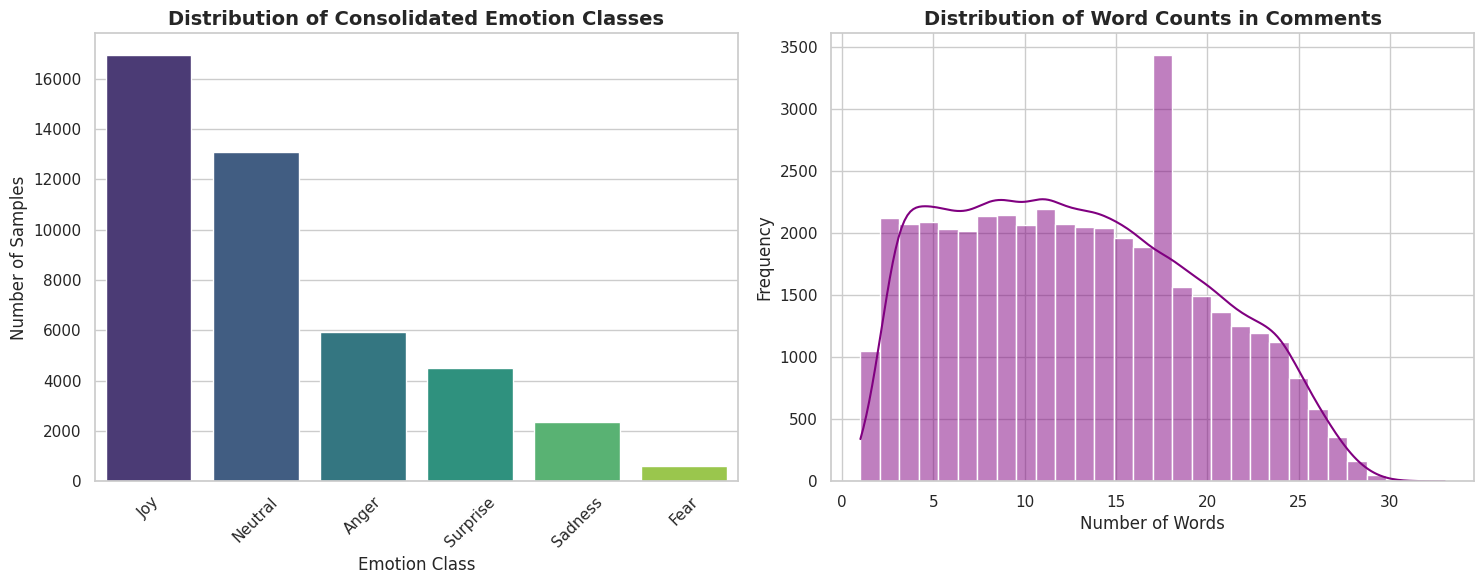

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style configuration
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 6))

# Subplot 1: Target Class Distribution
plt.subplot(1, 2, 1)
sns.countplot(
    data=clean_train,
    x='emotion',
    order=clean_train['emotion'].value_counts().index,
    palette="viridis"
)
plt.title("Distribution of Consolidated Emotion Classes", fontsize=14, fontweight='bold')
plt.xlabel("Emotion Class", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=45)

# Subplot 2: Word Count Distribution Histogram
plt.subplot(1, 2, 2)
sns.histplot(
    data=clean_train,
    x='word_count',
    kde=True,
    color='purple',
    bins=30
)
plt.title("Distribution of Word Counts in Comments", fontsize=14, fontweight='bold')
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

### Print Sample Comments per Emotion (Qualitative Exploration)

In [ ]:
print(" --- SAMPLE TEXTS FOR EACH EMOTION CATEGORY --- \n")

# Loop through each unique emotion and display 2 real text examples
for emotion in clean_train['emotion'].unique():
    print(f"==================== {emotion.upper()} ====================")
    samples = clean_train[clean_train['emotion'] == emotion]['text'].head(2).values
    for i, sample in enumerate(samples, 1):
        print(f"Example {i}: \"{sample}\"\n")

 --- SAMPLE TEXTS FOR EACH EMOTION CATEGORY --- 

==================== NEUTRAL ====================
Example 1: "My favourite food is anything I didn't have to cook myself."

Example 2: "Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead"

==================== ANGER ====================
Example 1: "WHY THE FUCK IS BAYLESS ISOING"

Example 2: "Dirty Southern Wankers"

==================== FEAR ====================
Example 1: "To make her feel threatened"

Example 2: "Your coaching is terrible.... be ready and see how [NAME] uses [NAME]"

==================== SURPRISE ====================
Example 1: "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015."

Example 2: "Demographics? I don’t know anybody under 35 who has cable tv."

==================== JOY ====================
Example 1: "Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I wi

### copy clean dataset

In [ ]:
# Create explicit copies to ensure our dataframes are locked in memory for the next steps
df_train = clean_train.copy()
df_val = clean_val.copy()
df_test = clean_test.copy()

print(" Student 1 (Data Exploration) is complete!")

 Student 1 (Data Exploration) is complete!


### Data Exploration Insights

*   Dataset Adequacy: The combined dataset features over 50,000 text samples, which massively exceeds the project's minimum requirement of 1,000 samples. This gives our models plenty of data to learn from.

*   Class Imbalance: Our exploratory analysis shows a prominent class imbalance. The Neutral and Joy classes hold the largest share of the dataset, while Fear and Surprise are significantly less common. We will need to keep this in mind when analyzing model performance metrics like precision and recall.

*   Text Length Profile: The average social media comment is relatively short (around 12-15 words). Because the text is concise, our feature extraction methods (TF-IDF and BERT embeddings) will need to efficiently capture meaning from short contexts.

## 2.2 Text Preprocessing

In [ ]:

# TEXT PREPROCESSING & FEATURE EXTRACTION

!pip install gensim nltk --quiet

import re
import nltk
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
import pickle

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

print("All libraries loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 3.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


All libraries loaded successfully!


In [ ]:

#TEXT PREPROCESSING PIPELINE

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full preprocessing pipeline:
    1. Lowercase
    2. Remove URLs, special characters, numbers
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove special characters, numbers (keep only letters + spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # 4. Tokenize
    tokens = word_tokenize(text)

    # 5. Remove stopwords & short tokens (len < 2)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens  # return LIST of tokens (needed for Word2Vec later)

print("Preprocessing function defined!")

Preprocessing function defined!


In [ ]:
print("Applying preprocessing pipeline to all splits...")

# Apply preprocessing — returns list of tokens
df_train['tokens'] = df_train['text'].apply(preprocess_text)
df_val['tokens']   = df_val['text'].apply(preprocess_text)
df_test['tokens']  = df_test['text'].apply(preprocess_text)

# Create a joined-string version for TF-IDF (needs string input)
df_train['clean_text'] = df_train['tokens'].apply(lambda x: ' '.join(x))
df_val['clean_text']   = df_val['tokens'].apply(lambda x: ' '.join(x))
df_test['clean_text']  = df_test['tokens'].apply(lambda x: ' '.join(x))

# Verify
print("\nPreprocessing complete! Sample:")
print(df_train[['text', 'clean_text', 'emotion']].head(3))
print(f"\nVocab sample from first row: {df_train['tokens'].iloc[0]}")

Applying preprocessing pipeline to all splits...

Preprocessing complete! Sample:
                                                text  \
0  My favourite food is anything I didn't have to...   
1  Now if he does off himself, everyone will thin...   
2                     WHY THE FUCK IS BAYLESS ISOING   

                                          clean_text  emotion  
0                 favourite food anything didnt cook  Neutral  
1  everyone think he laugh screwing people instea...  Neutral  
2                                fuck bayless isoing    Anger  

Vocab sample from first row: ['favourite', 'food', 'anything', 'didnt', 'cook']


In [ ]:
# Show before/after to prove the pipeline works
print("=" * 60)
print("PREPROCESSING BEFORE vs AFTER — SAMPLE COMPARISON")
print("=" * 60)

for i in range(3):
    print(f"\n[{i+1}] BEFORE: {df_train['text'].iloc[i]}")
    print(f"    AFTER : {df_train['clean_text'].iloc[i]}")

# Check for any empty strings after preprocessing
empty_count = (df_train['clean_text'] == '').sum()
print(f"\nEmpty rows after preprocessing: {empty_count}")
if empty_count > 0:
    df_train = df_train[df_train['clean_text'] != '']
    print(f"Dropped {empty_count} empty rows.")

PREPROCESSING BEFORE vs AFTER — SAMPLE COMPARISON

[1] BEFORE: My favourite food is anything I didn't have to cook myself.
    AFTER : favourite food anything didnt cook

[2] BEFORE: Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead
    AFTER : everyone think he laugh screwing people instead actually dead

[3] BEFORE: WHY THE FUCK IS BAYLESS ISOING
    AFTER : fuck bayless isoing

Empty rows after preprocessing: 104
Dropped 104 empty rows.


In [ ]:
# FEATURE EXTRACTION — METHOD 1: TF-IDF
print("Training TF-IDF Vectorizer...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,   # keep top 10k words
    ngram_range=(1, 2),   # unigrams + bigrams (bonus points!)
    min_df=2,             # ignore very rare words
    sublinear_tf=True     # apply log normalization
)

# Fit ONLY on training data, transform all splits
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['clean_text'])
X_val_tfidf   = tfidf_vectorizer.transform(df_val['clean_text'])
X_test_tfidf  = tfidf_vectorizer.transform(df_test['clean_text'])

print(f"TF-IDF matrix shapes:")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")

# Peek at top features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample TF-IDF features: {feature_names[:20]}")

Training TF-IDF Vectorizer...
TF-IDF matrix shapes:
  Train : (43306, 10000)
  Val   : (5426, 10000)
  Test  : (5427, 10000)

Sample TF-IDF features: ['aa' 'aaa' 'ab' 'abandoned' 'abhorrent' 'ability' 'able' 'able get'
 'able help' 'able play' 'abnormal' 'abort' 'abortion' 'abroad' 'absence'
 'absolute' 'absolute favorite' 'absolute worst' 'absolutely'
 'absolutely amazing']


In [ ]:
#FEATURE EXTRACTION — METHOD 2: WORD2VEC
print("Training Word2Vec model on training corpus...")

# Train Word2Vec on training tokens only
w2v_model = Word2Vec(
    sentences=df_train['tokens'].tolist(),
    vector_size=100,   # 100-dimensional word vectors
    window=5,          # context window size
    min_count=2,       # ignore words appearing < 2 times
    workers=4,         # parallel threads
    epochs=10,
    seed=42
)


print(f"Word2Vec trained! Vocabulary size: {len(w2v_model.wv)}")
print(f"Example — vector for 'happy': {w2v_model.wv['happy'][:5]}...")
print(f"Most similar to 'angry': {w2v_model.wv.most_similar('angry', topn=5)}")

Training Word2Vec model on training corpus...
Word2Vec trained! Vocabulary size: 11492
Example — vector for 'happy': [ 0.5577322 -0.9736063 -0.9226629  0.25907   -0.6321972]...
Most similar to 'angry': [('target', 0.9741735458374023), ('upset', 0.9734792113304138), ('disingenuous', 0.9696903228759766), ('nauseous', 0.9685313105583191), ('b', 0.968134880065918)]


In [ ]:
def get_doc_vector(tokens, model, vector_size=100):
    """
    Average all word vectors in a document to get a
    single fixed-size document embedding.
    """
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    #If no words match, return a zero vector of length 100
    # instead of an empty list []
    if not vectors:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# Create document-level vectors for all splits
X_train_w2v = np.array([get_doc_vector(t, w2v_model) for t in df_train['tokens']])
X_val_w2v   = np.array([get_doc_vector(t, w2v_model) for t in df_val['tokens']])
X_test_w2v  = np.array([get_doc_vector(t, w2v_model) for t in df_test['tokens']])

print(f"Word2Vec document vector shapes:")
print(f"  Train : {X_train_w2v.shape}")
print(f"  Val   : {X_val_w2v.shape}")
print(f"  Test  : {X_test_w2v.shape}")

Word2Vec document vector shapes:
  Train : (43306, 100)
  Val   : (5426, 100)
  Test  : (5427, 100)




**Preprocessing Decisions:**
- Lowercasing was applied first so that "Happy" and "happy" are treated as the same word.
- URLs and special characters were stripped using `re.sub()` as they carry no emotional meaning in Reddit comments.
- Tokenization was done using `word_tokenize()` (NLTK) to split each sentence into individual word units.
- Stopwords were removed using `stopwords.words('english')` (NLTK) — common words like "the", "is", "and" add noise without helping emotion detection.
- **Lemmatization** was chosen over stemming using `WordNetLemmatizer().lemmatize()` (NLTK) because it produces real dictionary words (e.g. "running" → "run", "better" → "good"), which is important for Word2Vec to learn meaningful embeddings. Stemming would produce broken words like "runn" which hurts vector quality.
- 104 empty rows were dropped after preprocessing — these were very short texts (e.g. single emojis or symbols only) that became empty strings after cleaning and carried no usable signal.

**Feature Extraction Summary:**

| Method | Shape | Key Design Choice |
|--------|-------|-------------------|
| TF-IDF | (43306, 10000) | `ngram_range=(1,2)` captures negations like "not happy" as a single feature |
| Word2Vec | (43306, 100) | Trained from scratch on our corpus so it learns Reddit/social media vocabulary |

**Why both methods are needed:**
- `TfidfVectorizer()` (sklearn) is fast and interpretable — it tells the model which specific words matter most per document based on frequency.
- `Word2Vec()` (Gensim) captures semantic meaning — "angry" and "furious" get similar vectors even if they never appear in the same sentence. This gives Student 3 two different representations to compare model performance across.

In [ ]:
y_train = df_train['emotion']
y_val = df_val['emotion']
y_test = df_test['emotion']

print("=" * 55)
print("FINAL PREPROCESSING AND FEATURE EXTRACTION")
print("=" * 55)

print("\n[1] TFIDF SHAPES")
print(f"  Train : {X_train_tfidf.shape}")
print(f"  Val   : {X_val_tfidf.shape}")
print(f"  Test  : {X_test_tfidf.shape}")

print("\n[2] WORD2VEC SHAPES")
print(f"  Train : {X_train_w2v.shape}")
print(f"  Val   : {X_val_w2v.shape}")
print(f"  Test  : {X_test_w2v.shape}")

print("\n[3] LABELS")
print(f"  y_train : {y_train.shape} | Classes: {set(y_train)}")
print(f"  y_val   : {y_val.shape}")
print(f"  y_test  : {y_test.shape}")

FINAL PREPROCESSING AND FEATURE EXTRACTION

[1] TFIDF SHAPES
  Train : (43306, 10000)
  Val   : (5426, 10000)
  Test  : (5427, 10000)

[2] WORD2VEC SHAPES
  Train : (43306, 100)
  Val   : (5426, 100)
  Test  : (5427, 100)

[3] LABELS
  y_train : (43306,) | Classes: {'Fear', 'Anger', 'Sadness', 'Neutral', 'Joy', 'Surprise'}
  y_val   : (5426,)
  y_test  : (5427,)


In [ ]:
# ============================================================
# STUDENT 2 COMPLETE — HANDOFF SUMMARY FOR STUDENT 3
# ============================================================
#
# Variables ready to use directly (no reloading needed):
#
# FOR TF-IDF MODELS (Naive Bayes, SVM, Logistic Regression):
#   X_train_tfidf  → sparse matrix (43306, 10000)
#   X_val_tfidf    → sparse matrix (5426, 10000)
#   X_test_tfidf   → sparse matrix (5427, 10000)
#
# FOR WORD2VEC MODELS (SVM, Logistic Regression):
#   X_train_w2v    → numpy array (43306, 100)
#   X_val_w2v      → numpy array (5426, 100)
#   X_test_w2v     → numpy array (5427, 100)
#
# LABELS (use for ALL models):
#   y_train / y_val / y_test  → emotion strings
#   Classes: Neutral, Joy, Anger, Sadness, Fear, Surprise
#
# NOTE: Fit TF-IDF only on training data (already done).
#       Use tfidf_vectorizer.transform() for new text in Streamlit.
#       Use get_doc_vector() + w2v_model for Word2Vec inference.
# ============================================================

print("Student 2 (Preprocessing & Feature Extraction) complete!")
print("Student 3 — all variables are live in memory, start coding below, THEN DELETE.")

Student 2 (Preprocessing & Feature Extraction) complete!
Student 3 — all variables are live in memory, start coding below, THEN DELETE.
